In [ ]:
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
from sklearn.datasets import make_moons
x, y = make_moons(n_samples=300, noise=0.2, random_state=42)
y = y.reshape(-1, 1)  # shape (300,1) to match your code's expectations

In [ ]:
# x = np.array([[0,0],[0,1],[1,0],[1,1]])
# y = np.array([[0],[1],[1],[0]])

w1 = np.random.randn(2,16) * 1
b1 = np.zeros(1)

w2 = np.random.randn(16,1) * 1
b2 = np.zeros(1)

In [ ]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [ ]:
def sigmoid(z):
  return 1/(1+np.exp(-z))

In [ ]:
def forward(x,w,b):
  z = x@w + b
  a = sigmoid(z)
  return (z,a)

In [ ]:
def compute_loss(p,y):
  loss = -(y*np.log(p) + (1-y)*np.log(1-p))
  return np.mean(loss)

In [ ]:
def backward(z1,a1,z2,a2,x,y,w2):
  dz2 = a2 -y
  dw2 = a1.T @ dz2
  db2 = np.sum(dz2, axis=0, keepdims=True)
  da1 = dz2 @ w2.T
  dz1 = da1 * a1 * (1-a1)
  dw1 = x.T @ dz1
  db1 = np.sum(dz1, axis=0, keepdims=True)

  return dw1,db1,dw2,db2

In [ ]:
learn_rate = 0.1
losses = []
accuracy=[]
for i in range(10000):
  z1,a1 = forward(x_train,w1,b1)
  z2,a2 = forward(a1,w2,b2)
  dw1,db1,dw2,db2 = backward(z1,a1,z2,a2,x_train,y_train,w2)
  w1 = w1 - dw1 * learn_rate
  b1 = b1 - db1 * learn_rate
  w2 = w2 - dw2 * learn_rate
  b2 = b2 - db2 * learn_rate
  if(i%500==0):
    print(compute_loss(a2,y_train))
    losses.append(compute_loss(a2,y_train))
    train_preds = np.round(a2)
    train_acc = np.mean(train_preds == y_train)
    accuracy.append(train_acc)
    print(train_acc)

1.1614634866992726
0.48333333333333334
0.07558935311864137
0.9666666666666667
0.06956675427959197
0.9666666666666667
0.06655633897788
0.9666666666666667
0.06447982758292327
0.9666666666666667
0.06307820938578408
0.9625
0.062134179945610706
0.9625
0.0614551953533236
0.9666666666666667
0.060931909154327814
0.9666666666666667
0.06050526023983459
0.9666666666666667
0.060141651517865276
0.9666666666666667
0.05982055657353657
0.9666666666666667
0.059528517822977786
0.9666666666666667
0.05925609919441756
0.9708333333333333
0.05899624260358502
0.9708333333333333
0.05874340053291772
0.9708333333333333
0.05849326889039409
0.9708333333333333
0.05824295863563687
0.9708333333333333
0.057991077082666716
0.9708333333333333
0.05773735075934051
0.9708333333333333


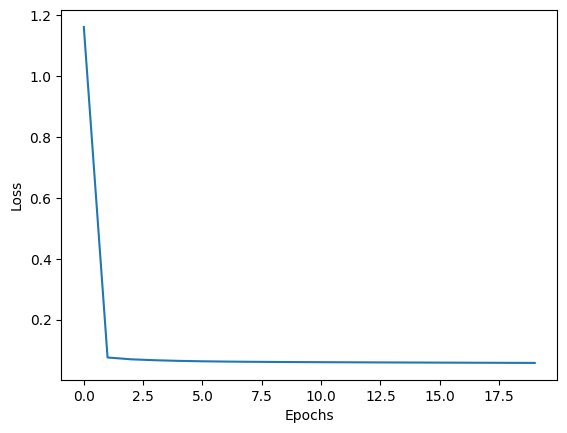

In [ ]:
plt.plot(losses)
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.show()

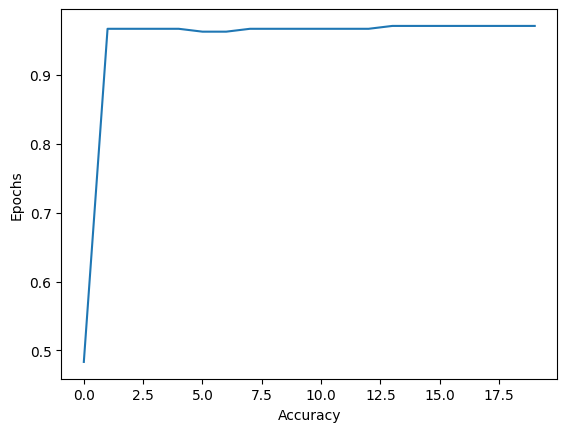

In [ ]:
plt.plot(accuracy)
plt.xlabel("Accuracy")
plt.ylabel("Epochs")
plt.show()

In [ ]:
a1_test = forward(x_test,w1,b1)[1]
a2_test = forward(a1_test,w2,b2)[1]

test_preds = np.round(a2_test)
test_acc = np.mean(test_preds == y_test)
print(test_acc)


0.9666666666666667


In [ ]:
z1, a1 = forward(x, w1, b1)
z2, a2 = forward(a1, w2, b2)
print(a2)
print(np.round(a2))

[[4.67339541e-04]
 [9.96771425e-01]
 [9.98654219e-01]
 [3.08415322e-03]]
[[0.]
 [1.]
 [1.]
 [0.]]
